### Data Cleaning Notebook Explanation

This notebook performs data cleaning and preprocessing on agrivoltaic system sensor data from multiple months (May, June, July, August, October). Below is a breakdown of each section:

### Importing Required Libraries

In this cell, we import three essential Python libraries for data analysis and manipulation:

- `os`: This module provides a way of using operating system-dependent functionality, such as file path management.
- `pandas as pd`: Pandas is a powerful library used for data manipulation and analysis. It provides data structures like DataFrames to handle structured data efficiently.
- `numpy as np`: NumPy is used for numerical computations. It provides support for arrays and mathematical functions used during data processing.

These libraries are the foundation for most data cleaning, preprocessing, and analysis tasks in Python.

In [1]:
import os
import pandas as pd
import numpy as np

### Setting Up Project Directory Structure

This cell defines and prepares the directory structure needed for organizing the project:

1. **Get Current and Parent Directory:**
   - `os.getcwd()` gets the current working directory.
   - `os.path.dirname(current_dir)` moves one level up to set the project root directory.

2. **Define Folder Paths:**
   - `data_dir` stores all data-related folders.
   - `raw_dir` is for raw (original) data.
   - `processed_dir` is for cleaned and processed data.
   - `results_dir` is for storing any outputs, figures, or analysis results.
   - `docs_dir` is for documentation files.

3. **Create Directories If Not Exist:**
   - `os.makedirs(..., exist_ok=True)` ensures these directories are created only if they don't already exist. This helps avoid errors when re-running the notebook.

This setup ensures the project is well-structured, organized, and reproducible.

In [3]:
# Get working directory
current_dir = os.getcwd()
# Go one directory up to the root directory
project_root_dir = os.path.dirname(current_dir)
# Define paths to the data folders
data_dir = os.path.join(project_root_dir, 'Data')
raw_dir = os.path.join(data_dir, 'Raw')
processed_dir = os.path.join(data_dir, 'Processed')
# Define paths to results folder
results_dir = os.path.join(project_root_dir, 'Results')
# Define paths to docs folder
docs_dir = os.path.join(project_root_dir, 'Docs')

# Create directories if they do not exist
os.makedirs(raw_dir, exist_ok = True)
os.makedirs(processed_dir, exist_ok = True)
os.makedirs(results_dir, exist_ok = True)
os.makedirs(docs_dir, exist_ok = True)

### Loading Monthly Datasets

In this step, we load the monthly CSV files containing raw data into separate DataFrames:

- `os.path.join(raw_dir, "May.csv")` constructs the full file path to the May dataset (similar for June, July, August, and October).
- `pd.read_csv(...)` is used to read each CSV file into a Pandas DataFrame.

**Parameters used in `read_csv`:**
- `na_values="?"`: Interprets the `?` symbol as a missing value (`NaN`).
- `skipinitialspace=True`: Removes leading spaces after delimiters to clean up messy column values.

We use `.head()` to preview the first few rows of each dataset.

Each month’s data is now loaded and ready for inspection or merging.

In [5]:
may = os.path.join(raw_dir,"May.csv")
may_df = pd.read_csv(may, na_values="?",skipinitialspace=True)
may_df.head()

,DATE,TIME,AG-PV P3/Irr (W/m2),AG-PV P3/T (oC),AO-TI P1/RH (%),AO-TI P1/T (oC),AO-TI P2/RH (%),AO-TI P2/T (oC),AO-SS P1/RH (%),AO-SS P1/T (oC),...,AG-TI P3/T (oC),AO-TI P3/RH (%),AO-TI P3/T (oC),AG-SS P3/RH (%),AG-SS P3/T (oC),AO-SS P3/RH (%),AO-SS P3/T (oC),WS/RH (%),WS/T (oC),WS/P (mm)
0,5/1/2024,12:00:00 AM,0.0,NaN,NaN,NaN,68.2,30.4,3.36,32.13,...,31.5,67.0,30.9,4.77,32.35,4.29,30.76,64.8,31.4,NaN
1,5/1/2024,12:05:00 AM,0.0,NaN,NaN,NaN,68.5,30.4,3.36,32.08,...,31.4,67.2,30.9,4.74,32.32,4.29,30.71,65.3,31.3,NaN
2,5/1/2024,12:10:00 AM,0.0,NaN,NaN,NaN,68.7,30.3,3.36,32.03,...,31.3,67.6,30.8,4.74,32.25,4.29,30.68,65.6,31.2,NaN
3,5/1/2024,12:15:00 AM,0.0,NaN,NaN,NaN,69.1,30.3,3.36,31.96,...,31.3,68.1,30.7,4.74,32.23,4.29,30.64,66.2,31.1,NaN
4,5/1/2024,12:20:00 AM,0.0,NaN,NaN,NaN,69.4,30.3,3.36,31.94,...,31.2,68.5,30.7,4.74,32.18,4.29,30.59,66.8,31.0,NaN


In [7]:
june = os.path.join(raw_dir,"June.csv")
june_df = pd.read_csv(june, na_values="?",skipinitialspace=True)
june_df.head()

,DATE,TIME,AG-PV P3/Irr (W/m2),AG-PV P3/T (oC),AO-TI P1/RH (%),AO-TI P1/T (oC),AO-TI P2/RH (%),AO-TI P2/T (oC),AO-SS P1/RH (%),AO-SS P1/T (oC),...,AG-TI P3/T (oC),AO-TI P3/RH (%),AO-TI P3/T (oC),AG-SS P3/RH (%),AG-SS P3/T (oC),AO-SS P3/RH (%),AO-SS P3/T (oC),WS/RH (%),WS/T (oC),WS/P (mm)
0,6/1/2024,12:00:00 AM,0.0,NaN,NaN,NaN,86.9,26.8,13.05,27.37,...,NaN,97.2,24.7,0.0,27.40,0.0,26.66,83.4,28.0,NaN
1,6/1/2024,12:05:00 AM,0.0,NaN,NaN,NaN,86.9,26.8,13.05,27.37,...,NaN,97.2,24.7,0.0,27.55,0.0,26.73,83.2,28.0,NaN
2,6/1/2024,12:10:00 AM,0.0,NaN,NaN,NaN,86.9,26.9,13.05,27.33,...,NaN,97.2,24.7,0.0,27.52,0.0,26.66,83.0,28.1,NaN
3,6/1/2024,12:15:00 AM,0.0,NaN,NaN,NaN,86.8,26.9,13.05,27.30,...,NaN,97.2,24.7,0.0,27.45,0.0,26.78,83.3,28.0,NaN
4,6/1/2024,12:20:00 AM,0.0,NaN,NaN,NaN,86.7,27.0,13.05,27.30,...,NaN,97.2,24.7,0.0,27.35,0.0,26.76,83.5,28.0,NaN


In [9]:
july = os.path.join(raw_dir,"July.csv")
july_df = pd.read_csv(july, na_values="?",skipinitialspace=True)
july_df.head()

,DATE,TIME,AG-PV P3/Irr (W/m2),AG-PV P3/T (oC),AO-TI P1/RH (%),AO-TI P1/T (oC),AO-TI P2/RH (%),AO-TI P2/T (oC),AO-SS P1/RH (%),AO-SS P1/T (oC),...,AG-TI P3/T (oC),AO-TI P3/RH (%),AO-TI P3/T (oC),AG-SS P3/RH (%),AG-SS P3/T (oC),AO-SS P3/RH (%),AO-SS P3/T (oC),WS/RH (%),WS/T (oC),WS/P (mm)
0,7/1/2024,5:25:00 AM,0,NaN,NaN,NaN,95.0,25.4,24.03,25.52,...,NaN,NaN,NaN,NaN,NaN,27.08,25.39,95.2,23.7,NaN
1,7/1/2024,5:30:00 AM,0,NaN,NaN,NaN,95.0,25.4,24.03,25.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7/1/2024,5:35:00 AM,0,NaN,NaN,NaN,95.0,25.4,24.03,25.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7/1/2024,5:40:00 AM,0,NaN,NaN,NaN,95.0,25.4,24.03,25.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7/1/2024,5:45:00 AM,0,NaN,NaN,NaN,95.0,25.4,24.03,25.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
august = os.path.join(raw_dir,"August.csv")
august_df = pd.read_csv(august, na_values="?",skipinitialspace=True)
august_df.head()

,DATE,TIME,AG-PV P3/Irr (W/m2),AG-PV P3/T (oC),AO-TI P1/RH (%),AO-TI P1/T (oC),AO-TI P2/RH (%),AO-TI P2/T (oC),AO-SS P1/RH (%),AO-SS P1/T (oC),...,AG-TI P3/T (oC),AO-TI P3/RH (%),AO-TI P3/T (oC),AG-SS P3/RH (%),AG-SS P3/T (oC),AO-SS P3/RH (%),AO-SS P3/T (oC),WS/RH (%),WS/T (oC),WS/P (mm)
0,8/1/2024,6:30:00 AM,57,NaN,NaN,NaN,89.4,24.2,14.09,24.44,...,NaN,0,0,17.3,24.64,20.24,24.77,91.4,24,NaN
1,8/1/2024,6:35:00 AM,69,NaN,NaN,NaN,87.8,24.8,14.09,24.47,...,NaN,0,0,17.36,24.64,20.34,24.79,90.5,24.3,NaN
2,8/1/2024,6:40:00 AM,78,NaN,NaN,NaN,87.3,25.1,14.14,24.52,...,NaN,0,0,17.36,24.64,20.34,24.82,90.3,24.5,NaN
3,8/1/2024,6:45:00 AM,91,NaN,NaN,NaN,86.8,25.3,14.18,24.57,...,NaN,0,0,17.36,24.67,20.4,24.89,90,24.7,NaN
4,8/1/2024,6:50:00 AM,96,NaN,NaN,NaN,86.2,25.5,14.14,24.62,...,NaN,0,0,17.36,24.69,20.34,24.94,89.5,24.8,NaN


In [13]:
october = os.path.join(raw_dir,"October.csv")
october_df = pd.read_csv(october, na_values="?",skipinitialspace=True)
october_df.head()

,DATE,TIME,AG-PV P3/Irr (W/m2),AG-PV P3/T (oC),AO-TI P1/RH (%),AO-TI P1/T (oC),AO-TI P2/RH (%),AO-TI P2/T (oC),AO-SS P1/RH (%),AO-SS P1/T (oC),...,AG-TI P3/T (oC),AO-TI P3/RH (%),AO-TI P3/T (oC),AG-SS P3/RH (%),AG-SS P3/T (oC),AO-SS P3/RH (%),AO-SS P3/T (oC),WS/RH (%),WS/T (oC),WS/P (mm)
0,10/10/2024,12:00:00 AM,0.0,NaN,NaN,NaN,0.0,0.0,21.23,27.03,...,NaN,NaN,NaN,NaN,NaN,27.76,27.77,89.8,24.9,NaN
1,10/10/2024,12:05:00 AM,0.0,NaN,NaN,NaN,0.0,0.0,21.23,27.03,...,NaN,NaN,NaN,NaN,NaN,27.76,27.74,90.4,24.9,NaN
2,10/10/2024,12:10:00 AM,0.0,NaN,NaN,NaN,0.0,0.0,21.23,27.05,...,NaN,NaN,NaN,NaN,NaN,27.76,27.72,90.5,25.0,NaN
3,10/10/2024,12:15:00 AM,0.0,NaN,NaN,NaN,0.0,0.0,21.18,27.05,...,NaN,NaN,NaN,NaN,NaN,27.76,27.72,90.4,24.9,NaN
4,10/10/2024,12:20:00 AM,0.0,NaN,NaN,NaN,0.0,0.0,21.18,27.05,...,NaN,NaN,NaN,NaN,NaN,27.76,27.69,90.6,24.9,NaN


### Comparing Column Consistency Across Monthly Datasets

After loading the monthly datasets (May to October), we verify whether they all contain the same columns. This is an essential step before merging the data.

**Steps performed:**
1. **Reading data**: Each month's CSV file is loaded again into a DataFrame using `pd.read_csv()` (though this is already done earlier, it’s shown here for clarity).
2. **Creating column sets**: A dictionary `columns_sets` stores the set of column names for each month. Using `set()` helps ignore column order and focuses only on column names.
3. **Pairwise comparison**: A nested loop compares the column sets of each month with all others.
   - If columns are the same: prints ✅ "Columns match".
   - If columns differ: prints ❌ "Columns DIFFER".

This ensures all datasets have consistent structure before concatenation.

In [15]:
may_df = pd.read_csv(os.path.join(raw_dir, "May.csv"), na_values="?", skipinitialspace=True)
june_df = pd.read_csv(os.path.join(raw_dir, "June.csv"), na_values="?", skipinitialspace=True)
july_df = pd.read_csv(os.path.join(raw_dir, "July.csv"), na_values="?", skipinitialspace=True)
august_df = pd.read_csv(os.path.join(raw_dir, "August.csv"), na_values="?", skipinitialspace=True)
october_df = pd.read_csv(os.path.join(raw_dir, "October.csv"), na_values="?", skipinitialspace=True)

# Store all column sets
columns_sets = {
    "May": set(may_df.columns),
    "June": set(june_df.columns),
    "July": set(july_df.columns),
    "August": set(august_df.columns),
    "October": set(october_df.columns),
}

# Compare all columns
for month1, cols1 in columns_sets.items():
    for month2, cols2 in columns_sets.items():
        if month1 != month2:
            if cols1 != cols2:
                print(f"❌ Columns DIFFER between {month1} and {month2}")
            else:
                print(f"✅ Columns match between {month1} and {month2}")

✅ Columns match between May and June
✅ Columns match between May and July
✅ Columns match between May and August
✅ Columns match between May and October
✅ Columns match between June and May
✅ Columns match between June and July
✅ Columns match between June and August
✅ Columns match between June and October
✅ Columns match between July and May
✅ Columns match between July and June
✅ Columns match between July and August
✅ Columns match between July and October
✅ Columns match between August and May
✅ Columns match between August and June
✅ Columns match between August and July
✅ Columns match between August and October
✅ Columns match between October and May
✅ Columns match between October and June
✅ Columns match between October and July
✅ Columns match between October and August


## Understanding Dataset

### 📅 Date and Time
- **DATE**: The calendar date of the observation (formatted as dd/mm/yyyy).
- **TIME**: The time of day for the recorded measurements (likely in HH:MM format).

---

### ☀️ AG-PV (Agrivoltaic Photovoltaic Panel Sensors)
- **AG-PV P1/Irr (W/m2)**: Solar irradiance (sunlight power per unit area) measured at panel position 1.
- **AG-PV P1/T (oC)**: Temperature recorded near panel position 1.
- **AG-PV P2/Irr (W/m2)**: Irradiance at panel position 2.
- **AG-PV P2/T (oC)**: Temperature at panel position 2.
- **AG-PV P3/Irr (W/m2)**: Irradiance at panel position 3.
- **AG-PV P3/T (oC)**: Temperature at panel position 3.

---

### 🌱 AO-TI (Control Plot – Tin Roof Sensors)
- **AO-TI P1/RH (%)**: Relative humidity at control plot position 1.
- **AO-TI P1/T (oC)**: Temperature at control plot position 1.
- **AO-TI P2/RH (%)**: Humidity at position 2.
- **AO-TI P2/T (oC)**: Temperature at position 2.
- **AO-TI P3/RH (%)**: Humidity at position 3.
- **AO-TI P3/T (oC)**: Temperature at position 3.

---

### 🌱 AO-SS (Control Plot – Soil Sensors)
- **AO-SS P1/RH (%)**: Humidity at control soil position 1.
- **AO-SS P1/T (oC)**: Temperature at soil position 1.
- **AO-SS P2/RH (%)**: Humidity at position 2.
- **AO-SS P2/T (oC)**: Temperature at position 2.
- **AO-SS P3/RH (%)**: Humidity at position 3.
- **AO-SS P3/T (oC)**: Temperature at position 3.

---

### 🌱 AG-TI (Agrivoltaic Tin Roof Sensors)
- **AG-TI P1/RH (%)**: Humidity under panels at position 1.
- **AG-TI P1/T (oC)**: Temperature under panels at position 1.
- **AG-TI P2/RH (%)**: Humidity at position 2.
- **AG-TI P2/T (oC)**: Temperature at position 2.
- **AG-TI P3/RH (%)**: Humidity at position 3.
- **AG-TI P3/T (oC)**: Temperature at position 3.

---

### 🌱 AG-SS (Agrivoltaic Soil Sensors)
- **AG-SS P1/RH (%)**: Soil humidity under panels at position 1.
- **AG-SS P1/T (oC)**: Soil temperature at position 1.
- **AG-SS P2/RH (%)**: Humidity at position 2.
- **AG-SS P2/T (oC)**: Temperature at position 2.
- **AG-SS P3/RH (%)**: Humidity at position 3.
- **AG-SS P3/T (oC)**: Temperature at position 3.

---

### ☀️ PO-PV (Ground-Mounted PV Systems)
- **PO-PV/Irr (W/m2)**: Irradiance from ground-mounted solar panels.
- **PO-PV/T (oC)**: Temperature from ground-mounted solar panels.

---

### 🌦️ WS (Weather Station Readings)
- **WS/RH (%)**: Ambient relative humidity.
- **WS/T (oC)**: Ambient temperature.
- **WS/P (mm)**: Rainfall (precipitation) in millimeters.

---

### 📌 Extra Info
- **Month**: Name of the month (e.g., "May", "June"), useful for grouping and filtering.


### Checking Dataset Dimensions

To understand the structure of each month's dataset, we inspect their dimensions using the `.shape` attribute. This returns a tuple in the format `(number_of_rows, number_of_columns)`.

**Purpose:**
- To confirm that data was loaded correctly.
- To identify potential inconsistencies in row counts (e.g., missing data, incomplete days).

**Example code and usage:**
```python
may_df.shape      # Output: (rows, columns) for May
june_df.shape     # For June
july_df.shape     # For July
august_df.shape   # For August
october_df.shape  # For October

In [17]:
may_df.shape

(8497, 37)

In [19]:
june_df.shape

(6845, 37)

In [21]:
july_df.shape

(5542, 37)

In [23]:
august_df.shape

(5095, 37)

In [25]:
october_df.shape

(5777, 37)

### Combining Monthly Datasets

To create a unified dataset, each monthly DataFrame is first labeled with a new `Month` column. This step is optional, but it helps track where each record came from.

Then, `pd.concat()` merges all the monthly DataFrames vertically (row-wise) into one complete dataset called `all_data`. Setting `ignore_index=True` resets the index to maintain consistency.

Finally, `all_data.shape` shows the size of the combined dataset, and `all_data.head()` displays the first few rows for inspection.

In [27]:
# Add a 'Month' column to each DataFrame
may_df["Month"] = "May"
june_df["Month"] = "June"
july_df["Month"] = "July"
august_df["Month"] = "August"
october_df["Month"] = "October"

# Merge (concatenate) all data row-wise
all_data = pd.concat(
    [may_df, june_df, july_df, august_df, october_df],
    ignore_index=True
)

# Preview
print(all_data.shape)
print(all_data.head())

(31756, 38)
       DATE         TIME AG-PV P3/Irr (W/m2)  AG-PV P3/T (oC) AO-TI P1/RH (%)  \
0  5/1/2024  12:00:00 AM                 0.0              NaN             NaN   
1  5/1/2024  12:05:00 AM                 0.0              NaN             NaN   
2  5/1/2024  12:10:00 AM                 0.0              NaN             NaN   
3  5/1/2024  12:15:00 AM                 0.0              NaN             NaN   
4  5/1/2024  12:20:00 AM                 0.0              NaN             NaN   

  AO-TI P1/T (oC)  AO-TI P2/RH (%)  AO-TI P2/T (oC) AO-SS P1/RH (%)  \
0             NaN             68.2             30.4            3.36   
1             NaN             68.5             30.4            3.36   
2             NaN             68.7             30.3            3.36   
3             NaN             69.1             30.3            3.36   
4             NaN             69.4             30.3            3.36   

   AO-SS P1/T (oC)  ...  AO-TI P3/RH (%)  AO-TI P3/T (oC)  AG-SS P3/RH (%)

### Inspecting Unique Date Formats

We use `print(all_data["DATE"].unique())` to check the different date formats present in the `"DATE"` column.

This helps identify inconsistencies such as:
- Different delimiters (`/`, `_`, or space)
- Varying formats (e.g., `MM/DD/YYYY`, `DD/MM/YY`, `MM DD YY`)

By identifying these irregularities, we ensure proper conversion to a standard datetime format in later steps. It's an essential step before any time-based analysis or sorting.

In [29]:
print(all_data["DATE"].unique())

['5/1/2024' '5/2/2024' '5/3/2024' '5/4/2024' '5/5/2024' '5/6/2024'
 '5/7/2024' '5/8/2024' '5/9/2024' '5/10/2024' '5/11/2024' '5/12/2024'
 '5/13/2024' '5/14/2024' '5/15/2024' '5/16/2024' '5/17/2024' '5/18/2024'
 '5/19/2024' '5/20/2024' '5/21/2024' '5/22/2024' '5/23/2024' '5/24/2024'
 '5/25/2024' '5/26/2024' '5/27/2024' '5/28/2024' '5/29/2024' '5/30/2024'
 '5/31/2024' '6/1/2024' '6/2/2024' '6/3/2024' '6/4/2024' '6/5/2024'
 '6/6/2024' '6/7/2024' '6/8/2024' '6/9/2024' '6/10/2024' '6/11/2024'
 '6/12/2024' '6/13/2024' '6/14/2024' '6/15/2024' '6/16/2024' '6/17/2024'
 '6/18/2024' '6/19/2024' '6/20/2024' '6/21/2024' '6/22/2024' '6/23/2024'
 '6/24/2024' '6/25/2024' '6/26/2024' '6/27/2024' '6/28/2024' '6/29/2024'
 '6/30/2024' '7/1/2024' '7/2/2024' '7/3/2024' '7/4/2024' '7/5/2024'
 '7/6/2024' '7/7/2024' '7/8/2024' '7/9/2024' '7/10/2024' '7/11/2024'
 '7/12/2024' '7/13/2024' '7/14/2024' '7/15/2024' '7/16/2024' '7/17/2024'
 '7/18/2024' '7/19/2024' '7/20/2024' '7/21/2024' '7/22/2024' '7/23/2024'
 '7/2

### Checking the Shape of the Combined Dataset

We use `all_data.shape` to display the number of rows and columns in the merged dataset.

- The result is a tuple: `(number_of_rows, number_of_columns)`
- It helps us confirm that all monthly files have been successfully merged.
- Also useful to monitor how many records we're working with before and after data cleaning.

This step ensures that the data loading and concatenation process worked correctly.

In [31]:
all_data.shape

(31756, 38)

### 17. Checking and Removing Duplicate Rows

We use the following steps to handle duplicate rows in the dataset:

1. **`all_data.duplicated().sum()`**:  
   This counts how many rows are duplicates (i.e., exact copies of previous rows).  
   This is important to ensure data quality and avoid bias in analysis.

2. **`all_data = all_data.drop_duplicates()`**:  
   This removes all duplicated rows, keeping only the first occurrence.  
   Removing duplicates helps to reduce noise and redundancy in the dataset.

3. **`all_data.duplicated().sum()`** *(after removal)*:  
   We run the same check again to confirm that all duplicates have been successfully removed.  
   The result should now be `0`, confirming the dataset is clean from duplicates.

This ensures that every record in our dataset is unique.

In [33]:
all_data.duplicated().sum()

301

In [35]:
august_df.loc[[1803, 1804,1805,1807,1815]]

,DATE,TIME,AG-PV P3/Irr (W/m2),AG-PV P3/T (oC),AO-TI P1/RH (%),AO-TI P1/T (oC),AO-TI P2/RH (%),AO-TI P2/T (oC),AO-SS P1/RH (%),AO-SS P1/T (oC),...,AO-TI P3/RH (%),AO-TI P3/T (oC),AG-SS P3/RH (%),AG-SS P3/T (oC),AO-SS P3/RH (%),AO-SS P3/T (oC),WS/RH (%),WS/T (oC),WS/P (mm),Month
1803,8/13/2024,7:05:00 AM,68,NaN,NaN,NaN,0.0,0.0,10.05,24.97,...,0,0,15.05,25.22,16.24,25.12,89.7,24.9,NaN,August
1804,8/13/2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,August
1805,8/13/2024,7:10:00 AM,80,NaN,NaN,NaN,0.0,0.0,10.14,25.02,...,0,0,15.11,25.24,16.24,25.14,89.3,25,NaN,August
1807,8/13/2024,7:15:00 AM,92,NaN,NaN,NaN,0.0,0.0,10.14,25.09,...,0,0,15.11,25.24,16.24,25.17,89,25.1,NaN,August
1815,8/13/2024,7:35:00 AM,134,NaN,NaN,NaN,0.0,0.0,10.21,25.39,...,0,0,15.05,25.32,16.24,25.39,87.7,25.4,NaN,August


In [37]:
all_data = all_data.drop_duplicates()

In [39]:
all_data.duplicated().sum()

0

### Checking Missing Values

This step displays the number of missing values (`NaN`) in each column after the forward and backward filling operations. It helps verify whether additional cleaning is necessary.

In [41]:
all_data.isnull().sum()

DATE                       0
TIME                       4
AG-PV P3/Irr (W/m2)      259
AG-PV P3/T (oC)        27464
AO-TI P1/RH (%)        31296
AO-TI P1/T (oC)        31296
AO-TI P2/RH (%)         1357
AO-TI P2/T (oC)         1134
AO-SS P1/RH (%)          758
AO-SS P1/T (oC)          756
AO-SS P2/RH (%)        21734
AO-SS P2/T (oC)        21732
AG-PV P1/Irr (W/m2)     1208
AG-PV P1/T (oC)        26682
AG-PV P2/Irr (W/m2)      865
AG-PV P2/T (oC)        26076
AG-TI P1/RH (%)        28259
AG-TI P1/T (oC)        29951
AG-TI P2/RH (%)        30883
AG-TI P2/T (oC)        30884
AG-SS P1/RH (%)         7244
AG-SS P1/T (oC)         7233
AG-SS P2/RH (%)         6878
AG-SS P2/T (oC)         6886
PO-PV/Irr (W/m2)        1497
PO-PV/T (oC)           25686
AG-TI P3/RH (%)        24700
AG-TI P3/T (oC)        24701
AO-TI P3/RH (%)         7654
AO-TI P3/T (oC)         7673
AG-SS P3/RH (%)         7674
AG-SS P3/T (oC)         7672
AO-SS P3/RH (%)         6306
AO-SS P3/T (oC)         6315
WS/RH (%)     

### Summary: Handling Missing Values

We filled missing values in temperature, humidity, and irradiance columns using **forward fill** and **backward fill** methods. This technique preserves the natural trends in sensor data by using nearby valid values to fill gaps, avoiding the distortion that can come from using averages or other imputation techniques. It's especially effective for time-series environmental data.

In [45]:
columns_to_fill = [
    "TIME", "AG-PV P3/Irr (W/m2)", "AG-PV P3/T (oC)", "AO-TI P1/RH (%)", "AO-TI P1/T (oC)",
    "AO-TI P2/RH (%)", "AO-TI P2/T (oC)", "AO-SS P1/RH (%)", "AO-SS P1/T (oC)",
    "AO-SS P2/RH (%)", "AO-SS P2/T (oC)", "AG-PV P1/Irr (W/m2)", "AG-PV P1/T (oC)",
    "AG-PV P2/Irr (W/m2)", "AG-PV P2/T (oC)", "AG-TI P1/RH (%)", "AG-TI P1/T (oC)",
    "AG-TI P2/RH (%)", "AG-TI P2/T (oC)", "AG-SS P1/RH (%)", "AG-SS P1/T (oC)",
    "AG-SS P2/RH (%)", "AG-SS P2/T (oC)", "PO-PV/Irr (W/m2)", "PO-PV/T (oC)",
    "AG-TI P3/RH (%)", "AG-TI P3/T (oC)", "AO-TI P3/RH (%)", "AO-TI P3/T (oC)",
    "AG-SS P3/RH (%)", "AG-SS P3/T (oC)", "AO-SS P3/RH (%)", "AO-SS P3/T (oC)",
    "WS/RH (%)", "WS/T (oC)"
]

# Fill forward then backward for each column
for col in columns_to_fill:
    all_data.loc[:, col] = all_data[col].ffill().bfill()

we checked again for remaining missing values 

In [47]:
all_data.isnull().sum()

DATE                       0
TIME                       0
AG-PV P3/Irr (W/m2)        0
AG-PV P3/T (oC)            0
AO-TI P1/RH (%)            0
AO-TI P1/T (oC)            0
AO-TI P2/RH (%)            0
AO-TI P2/T (oC)            0
AO-SS P1/RH (%)            0
AO-SS P1/T (oC)            0
AO-SS P2/RH (%)            0
AO-SS P2/T (oC)            0
AG-PV P1/Irr (W/m2)        0
AG-PV P1/T (oC)            0
AG-PV P2/Irr (W/m2)        0
AG-PV P2/T (oC)            0
AG-TI P1/RH (%)            0
AG-TI P1/T (oC)            0
AG-TI P2/RH (%)            0
AG-TI P2/T (oC)            0
AG-SS P1/RH (%)            0
AG-SS P1/T (oC)            0
AG-SS P2/RH (%)            0
AG-SS P2/T (oC)            0
PO-PV/Irr (W/m2)           0
PO-PV/T (oC)               0
AG-TI P3/RH (%)            0
AG-TI P3/T (oC)            0
AO-TI P3/RH (%)            0
AO-TI P3/T (oC)            0
AG-SS P3/RH (%)            0
AG-SS P3/T (oC)            0
AO-SS P3/RH (%)            0
AO-SS P3/T (oC)            0
WS/RH (%)     

### Filling Missing Rainfall Values

The missing values in the **"WS/P (mm)"** column (which represents rainfall or precipitation) were replaced with **0**. This is a logical assumption because a missing rainfall reading typically indicates **no rain was recorded** rather than an error or sensor failure.

In [49]:
all_data.loc[:, "WS/P (mm)"] = all_data["WS/P (mm)"].fillna(0)

In [51]:
all_data.isnull().sum()

DATE                   0
TIME                   0
AG-PV P3/Irr (W/m2)    0
AG-PV P3/T (oC)        0
AO-TI P1/RH (%)        0
AO-TI P1/T (oC)        0
AO-TI P2/RH (%)        0
AO-TI P2/T (oC)        0
AO-SS P1/RH (%)        0
AO-SS P1/T (oC)        0
AO-SS P2/RH (%)        0
AO-SS P2/T (oC)        0
AG-PV P1/Irr (W/m2)    0
AG-PV P1/T (oC)        0
AG-PV P2/Irr (W/m2)    0
AG-PV P2/T (oC)        0
AG-TI P1/RH (%)        0
AG-TI P1/T (oC)        0
AG-TI P2/RH (%)        0
AG-TI P2/T (oC)        0
AG-SS P1/RH (%)        0
AG-SS P1/T (oC)        0
AG-SS P2/RH (%)        0
AG-SS P2/T (oC)        0
PO-PV/Irr (W/m2)       0
PO-PV/T (oC)           0
AG-TI P3/RH (%)        0
AG-TI P3/T (oC)        0
AO-TI P3/RH (%)        0
AO-TI P3/T (oC)        0
AG-SS P3/RH (%)        0
AG-SS P3/T (oC)        0
AO-SS P3/RH (%)        0
AO-SS P3/T (oC)        0
WS/RH (%)              0
WS/T (oC)              0
WS/P (mm)              0
Month                  0
dtype: int64

we checked shape of our dataset

In [53]:
all_data.shape

(31455, 38)

we check missing values again ta make sure there are no missing values

we checked for duplicates again and removed them

In [55]:
all_data.duplicated().sum()

4

In [57]:
all_data[all_data['TIME'].isna()]

,DATE,TIME,AG-PV P3/Irr (W/m2),AG-PV P3/T (oC),AO-TI P1/RH (%),AO-TI P1/T (oC),AO-TI P2/RH (%),AO-TI P2/T (oC),AO-SS P1/RH (%),AO-SS P1/T (oC),...,AO-TI P3/RH (%),AO-TI P3/T (oC),AG-SS P3/RH (%),AG-SS P3/T (oC),AO-SS P3/RH (%),AO-SS P3/T (oC),WS/RH (%),WS/T (oC),WS/P (mm),Month


In [59]:
all_data = all_data.drop_duplicates()

In [61]:
all_data.duplicated().sum()

0

### Summary Statistics (Descriptive Analysis)

We generated descriptive statistics for the numerical columns in the dataset using `all_data.describe()`. This includes the **count**, **mean**, **standard deviation**, **minimum**, **25th percentile (Q1)**, **median (Q2)**, **75th percentile (Q3)**, and **maximum** values. These insights help us:

- **Understand data spread and central tendency** for each sensor reading (e.g., temperature, humidity, irradiance).
- **Identify anomalies or outliers**, such as:
  - **PO-PV/T (oC)** has a minimum value of -109.2°C, which is physically unrealistic.
  - **AG-TI P1/RH (%)** has a maximum of 1034%, which exceeds the natural limit of 100%.
  - **AG-PV P2/Irr (W/m2)** shows a maximum of 3426 W/m², which is extremely high.

These statistics guided our decisions on how to detect and handle **outliers** and fill **missing values** effectively.


In [63]:
all_data.describe()

,AG-PV P3/T (oC),AO-TI P2/RH (%),AO-TI P2/T (oC),AO-SS P1/T (oC),AO-SS P2/RH (%),AO-SS P2/T (oC),AG-PV P1/Irr (W/m2),AG-PV P1/T (oC),AG-PV P2/Irr (W/m2),AG-TI P1/RH (%),AG-TI P1/T (oC),AG-SS P1/RH (%),AG-SS P2/RH (%),AG-SS P2/T (oC),PO-PV/T (oC)
count,31451.000000,31451.000000,31451.000000,31451.000000,31451.000000,31451.000000,31451.000000,31451.00000,31451.000000,31451.000000,31451.000000,31451.000000,31451.000000,31451.000000,31451.000000
mean,20.040886,46.898722,21.593556,30.462430,14.391562,29.121008,225.640895,19.50885,227.045190,10.129853,6.907088,10.094690,16.497711,27.542806,17.553584
std,2.750329,35.169373,15.433829,5.214082,9.502938,7.541589,281.493901,3.22739,280.643144,36.764946,7.796426,7.774594,10.633847,4.921042,17.594817
min,1.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.60000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,-109.200000
25%,20.100000,0.000000,0.000000,27.100000,4.290000,26.460000,0.000000,20.00000,0.000000,0.000000,0.000000,3.620000,9.400000,26.410000,20.000000
50%,20.300000,56.100000,27.400000,28.940000,16.690000,30.200000,95.000000,20.30000,101.000000,0.000000,10.000000,10.210000,18.340000,27.130000,20.300000
75%,20.800000,77.800000,32.400000,31.940000,23.130000,33.190000,377.000000,20.70000,381.000000,0.000000,10.000000,17.100000,27.040000,29.500000,20.900000
max,28.800000,98.800000,55.700000,89.700000,96.100000,45.210000,1315.000000,28.00000,3426.000000,1034.000000,28.110000,33.550000,33.570000,72.700000,58.800000


### Dataset Structure Overview (`all_data.info()`)

We used the `info()` method to inspect the structure and data types of the `all_data` DataFrame. This provided the following insights:

- **Total number of entries**: Matches the number of rows after concatenation and cleaning.
- **Column count**: Displays all sensor measurement columns (temperature, humidity, irradiance, etc.) along with time-related and metadata columns.
- **Data types**:
  - Most columns are of type `Object`, representing non-numerical measurements.
  - Time-related columns such as `DATE` and `TIME` may appear as `object` if not yet converted to a datetime format.
- **Missing values**: Displayed as the number of non-null entries per column, which we already handled using forward and backward filling.

This step confirmed the consistency of the dataset and readiness for analysis.

In [65]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31451 entries, 0 to 31755
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE                 31451 non-null  object 
 1   TIME                 31451 non-null  object 
 2   AG-PV P3/Irr (W/m2)  31451 non-null  object 
 3   AG-PV P3/T (oC)      31451 non-null  float64
 4   AO-TI P1/RH (%)      31451 non-null  object 
 5   AO-TI P1/T (oC)      31451 non-null  object 
 6   AO-TI P2/RH (%)      31451 non-null  float64
 7   AO-TI P2/T (oC)      31451 non-null  float64
 8   AO-SS P1/RH (%)      31451 non-null  object 
 9   AO-SS P1/T (oC)      31451 non-null  float64
 10  AO-SS P2/RH (%)      31451 non-null  float64
 11  AO-SS P2/T (oC)      31451 non-null  float64
 12  AG-PV P1/Irr (W/m2)  31451 non-null  float64
 13  AG-PV P1/T (oC)      31451 non-null  float64
 14  AG-PV P2/Irr (W/m2)  31451 non-null  float64
 15  AG-PV P2/T (oC)      31451 non-null  obje

### Cleaning Potential Invalid Entries in Selected Columns

To ensure data consistency and prepare for numeric operations, we performed the following steps on selected columns:

- **Targeted Columns**: A list of relevant sensor readings (e.g., temperature, humidity, irradiance, rainfall, etc.) and time identifiers were selected.
  
- **Step 1: Replace Invalid Characters**
  - Any occurrence of the string `'E'` (which may represent erroneous entries or exponential notation misreads) was replaced with `NaN` using `replace('E', np.nan)`.

- **Step 2: Type Inference**
  - After replacing invalid values, we used `infer_objects(copy=False)` to automatically convert object-type columns to appropriate types (e.g., `float`) wherever possible.

This step ensures the columns are ready for analysis and visualization by eliminating non-numeric artifacts and enforcing the correct data types.

In [67]:
all_data[all_data.isin(['E']).any(axis=1)]

,DATE,TIME,AG-PV P3/Irr (W/m2),AG-PV P3/T (oC),AO-TI P1/RH (%),AO-TI P1/T (oC),AO-TI P2/RH (%),AO-TI P2/T (oC),AO-SS P1/RH (%),AO-SS P1/T (oC),...,AO-TI P3/RH (%),AO-TI P3/T (oC),AG-SS P3/RH (%),AG-SS P3/T (oC),AO-SS P3/RH (%),AO-SS P3/T (oC),WS/RH (%),WS/T (oC),WS/P (mm),Month
0,5/1/2024,12:00:00 AM,0.0,21.7,E,E,68.2,30.4,3.36,32.13,...,67.0,30.9,4.77,32.35,4.29,30.76,64.8,31.4,0,May
1,5/1/2024,12:05:00 AM,0.0,21.7,E,E,68.5,30.4,3.36,32.08,...,67.2,30.9,4.74,32.32,4.29,30.71,65.3,31.3,0,May
2,5/1/2024,12:10:00 AM,0.0,21.7,E,E,68.7,30.3,3.36,32.03,...,67.6,30.8,4.74,32.25,4.29,30.68,65.6,31.2,0,May
3,5/1/2024,12:15:00 AM,0.0,21.7,E,E,69.1,30.3,3.36,31.96,...,68.1,30.7,4.74,32.23,4.29,30.64,66.2,31.1,0,May
4,5/1/2024,12:20:00 AM,0.0,21.7,E,E,69.4,30.3,3.36,31.94,...,68.5,30.7,4.74,32.18,4.29,30.59,66.8,31.0,0,May
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31751,10/31/2024,11:35:00 PM,0.0,20.2,E,E,0.0,0.0,16.34,26.83,...,31.36,91.5,23.9,0.0,0.0,89.7,84.8,25.9,0,October
31752,10/31/2024,11:40:00 PM,0.0,20.2,E,E,0.0,0.0,16.34,26.83,...,31.36,91.5,23.9,0.0,0.0,89.7,86.0,25.7,0,October
31753,10/31/2024,11:45:00 PM,0.0,20.2,E,E,0.0,0.0,16.34,26.81,...,31.36,91.5,23.9,0.0,0.0,89.7,86.3,25.6,0,October
31754,10/31/2024,11:50:00 PM,0.0,20.2,E,E,0.0,0.0,16.34,26.78,...,31.36,91.5,23.9,0.0,0.0,89.7,85.7,25.6,0,October


In [71]:
cols = [
    'DATE', 'TIME', 'AG-PV P3/Irr (W/m2)', 'AG-PV P3/T (oC)', 'AO-TI P1/RH (%)',
    'AO-TI P2/RH (%)', 'AO-TI P2/T (oC)', 'AO-SS P1/RH (%)', 'AO-TI P1/T (oC)',
    'AO-SS P1/T (oC)', 'AO-SS P2/RH (%)', 'AO-SS P2/T (oC)',
    'AG-PV P1/Irr (W/m2)', 'AG-PV P1/T (oC)', 'AG-PV P2/Irr (W/m2)',
    'AG-PV P2/T (oC)', 'AG-TI P1/RH (%)', 'AG-TI P1/T (oC)',
    'AG-TI P2/RH (%)', 'AG-TI P2/T (oC)', 'AG-SS P1/RH (%)',
    'AG-SS P1/T (oC)', 'AG-SS P2/RH (%)', 'AG-SS P2/T (oC)',
    'PO-PV/Irr (W/m2)', 'PO-PV/T (oC)', 'AG-TI P3/RH (%)',
    'AG-TI P3/T (oC)', 'AO-TI P3/RH (%)', 'AO-TI P3/T (oC)',
    'AG-SS P3/RH (%)', 'AG-SS P3/T (oC)', 'AO-SS P3/RH (%)',
    'AO-SS P3/T (oC)', 'WS/RH (%)', 'WS/T (oC)', 'WS/P (mm)', 'Month',
]
all_data[cols] = all_data[cols].replace('E', np.nan).infer_objects(copy=False)

### Checking for Remaining Missing Values

After cleaning and converting the relevant columns, we used `all_data.isnull().sum()` to **summarize the count of missing values per column**.

This step provides a quick overview of:
- Which columns still contain `NaN` values.
- The extent of missing data that might need further imputation or analysis.

It helps inform the next steps in data cleaning, such as whether forward/backward filling, interpolation, or model-based imputation is needed.

In [73]:
all_data.isnull().sum()

DATE                       0
TIME                      11
AG-PV P3/Irr (W/m2)       38
AG-PV P3/T (oC)            0
AO-TI P1/RH (%)        31451
AO-TI P1/T (oC)        31451
AO-TI P2/RH (%)            0
AO-TI P2/T (oC)            0
AO-SS P1/RH (%)            1
AO-SS P1/T (oC)            0
AO-SS P2/RH (%)            0
AO-SS P2/T (oC)            0
AG-PV P1/Irr (W/m2)        0
AG-PV P1/T (oC)            0
AG-PV P2/Irr (W/m2)        0
AG-PV P2/T (oC)            1
AG-TI P1/RH (%)            0
AG-TI P1/T (oC)            0
AG-TI P2/RH (%)        14224
AG-TI P2/T (oC)        14225
AG-SS P1/RH (%)            0
AG-SS P1/T (oC)            5
AG-SS P2/RH (%)            0
AG-SS P2/T (oC)            0
PO-PV/Irr (W/m2)          44
PO-PV/T (oC)               0
AG-TI P3/RH (%)        15372
AG-TI P3/T (oC)        17742
AO-TI P3/RH (%)           19
AO-TI P3/T (oC)           19
AG-SS P3/RH (%)           19
AG-SS P3/T (oC)           19
AO-SS P3/RH (%)           19
AO-SS P3/T (oC)           19
WS/RH (%)     

<Axes: >

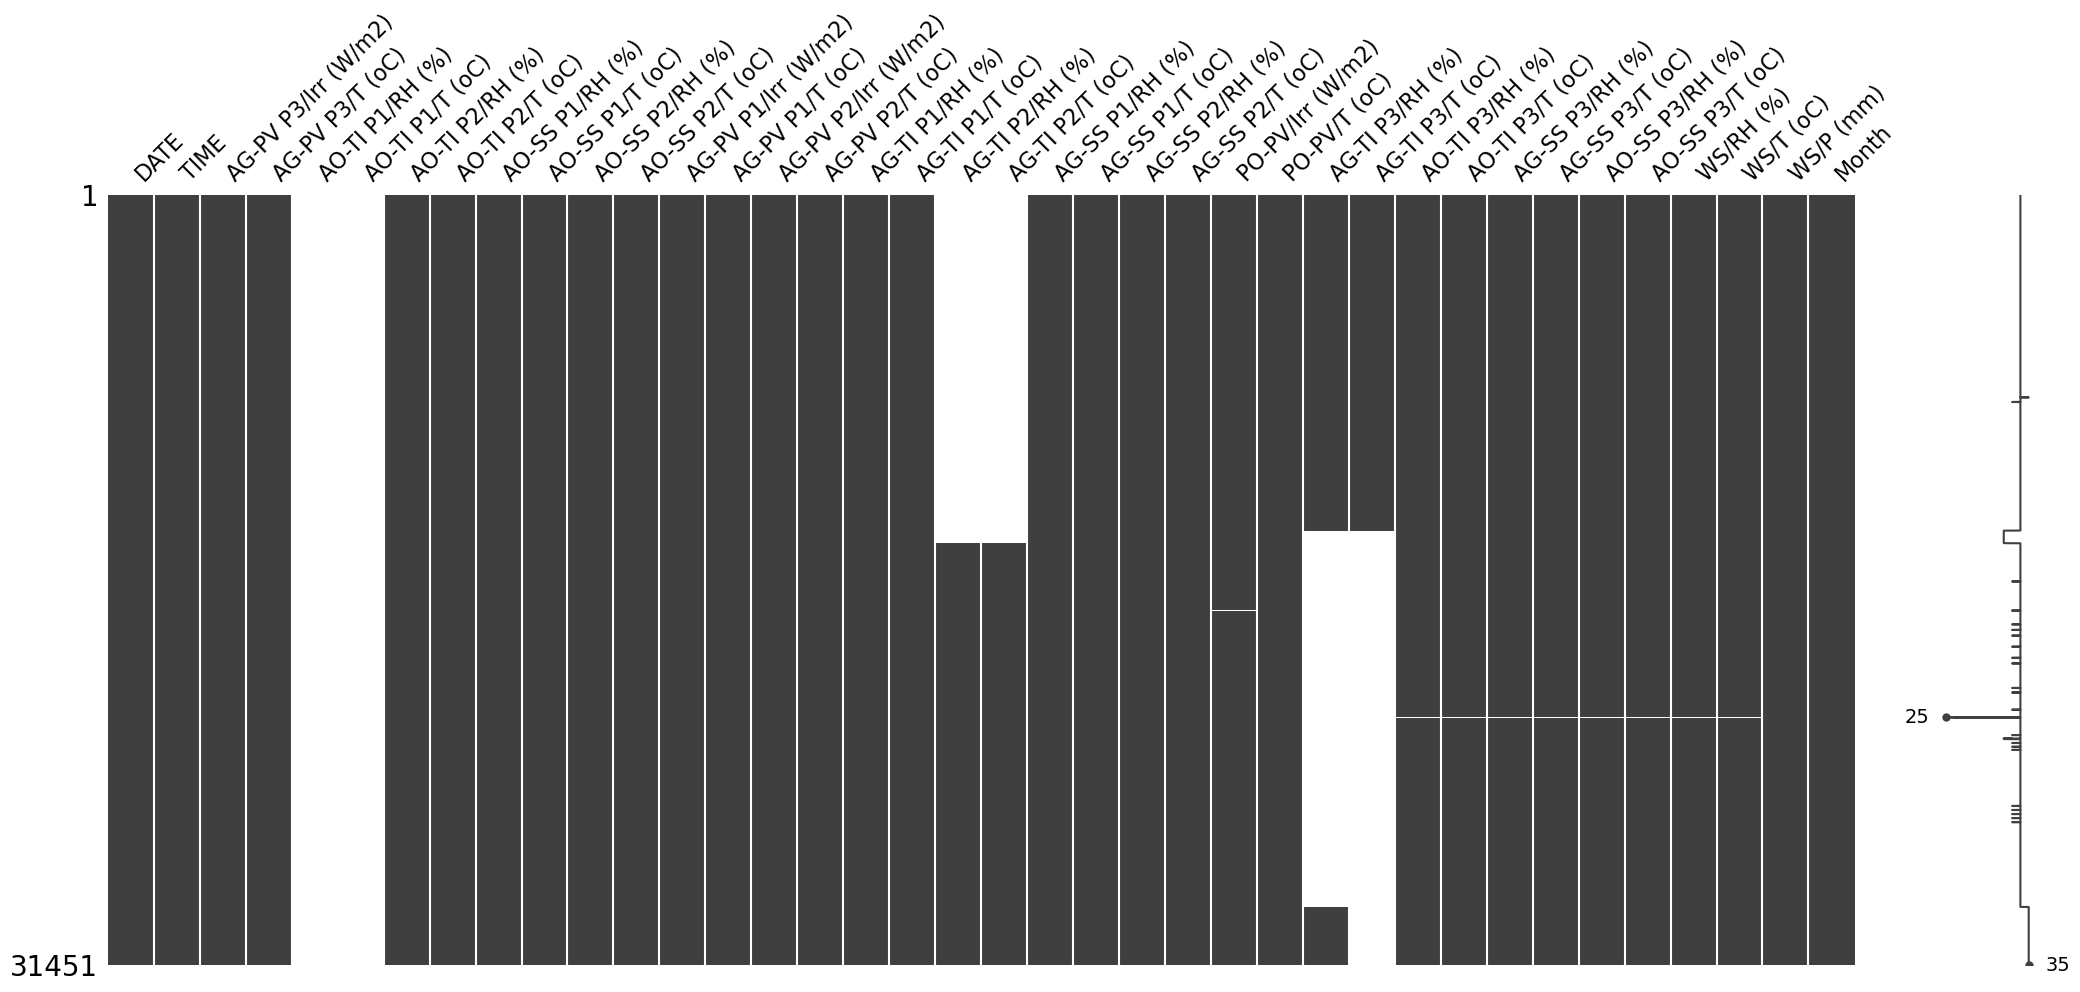

In [75]:
import missingno as msno
msno.matrix(all_data)

In [77]:
all_data = all_data.drop(columns=['AO-TI P1/RH (%)', 'AO-TI P1/T (oC)', 'AG-TI P2/RH (%)', 'AG-TI P2/T (oC)', 'AG-TI P3/RH (%)', 'AG-TI P3/T (oC)'])

<Axes: >

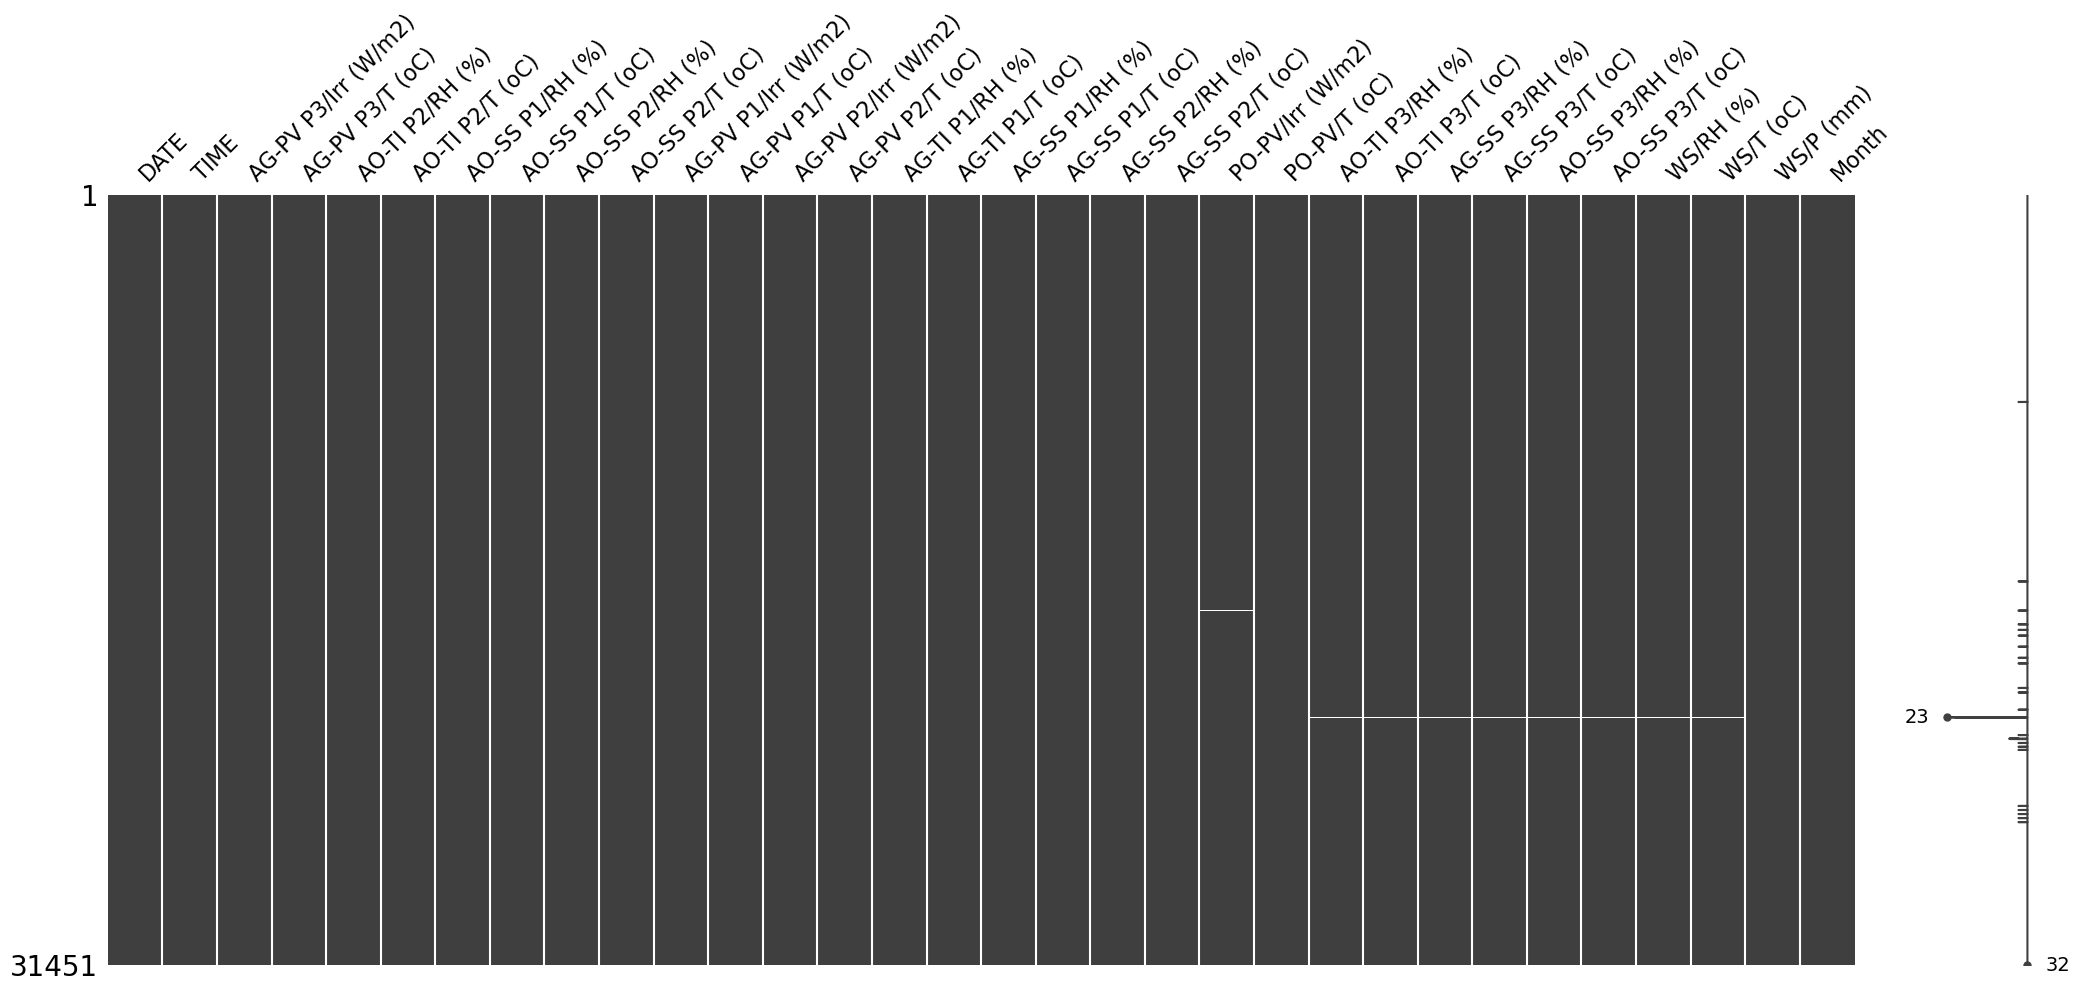

In [79]:
import missingno as msno
msno.matrix(all_data)

### Final Missing Value Imputation

For the columns still containing missing values, we applied **forward fill (`ffill`) followed by backward fill (`bfill`)**.

This approach ensures:
- If a value is missing, it takes the previous valid observation (forward fill).
- If the forward value is also missing (e.g., at the start), it takes the next valid observation (backward fill).

This method is ideal for **time-series-like data** such as temperature, humidity, and sensor readings, where neighboring values are often similar.

It helps maintain the continuity and pattern of the dataset without introducing bias that could occur from arbitrary values (like mean or median).

In [81]:
all_data.isnull().sum()

DATE                    0
TIME                   11
AG-PV P3/Irr (W/m2)    38
AG-PV P3/T (oC)         0
AO-TI P2/RH (%)         0
AO-TI P2/T (oC)         0
AO-SS P1/RH (%)         1
AO-SS P1/T (oC)         0
AO-SS P2/RH (%)         0
AO-SS P2/T (oC)         0
AG-PV P1/Irr (W/m2)     0
AG-PV P1/T (oC)         0
AG-PV P2/Irr (W/m2)     0
AG-PV P2/T (oC)         1
AG-TI P1/RH (%)         0
AG-TI P1/T (oC)         0
AG-SS P1/RH (%)         0
AG-SS P1/T (oC)         5
AG-SS P2/RH (%)         0
AG-SS P2/T (oC)         0
PO-PV/Irr (W/m2)       44
PO-PV/T (oC)            0
AO-TI P3/RH (%)        19
AO-TI P3/T (oC)        19
AG-SS P3/RH (%)        19
AG-SS P3/T (oC)        19
AO-SS P3/RH (%)        19
AO-SS P3/T (oC)        19
WS/RH (%)              19
WS/T (oC)              19
WS/P (mm)               6
Month                   0
dtype: int64

In [83]:
columns_with_missing = [
    "TIME",
    "AG-PV P3/Irr (W/m2)",
    "AO-SS P1/RH (%)",
    "AG-PV P2/T (oC)",
    "AG-SS P1/T (oC)",
    "PO-PV/Irr (W/m2)",
    "AO-TI P3/RH (%)",
    "AO-TI P3/T (oC)",
    "AG-SS P3/RH (%)",
    "AG-SS P3/T (oC)",
    "AO-SS P3/RH (%)",
    "AO-SS P3/T (oC)",
    "WS/RH (%)",
    "WS/T (oC)",
    "WS/P (mm)",
]
for col in columns_with_missing:
    all_data[col] = all_data[col].ffill().bfill()

In [85]:
all_data.isnull().sum()

DATE                   0
TIME                   0
AG-PV P3/Irr (W/m2)    0
AG-PV P3/T (oC)        0
AO-TI P2/RH (%)        0
AO-TI P2/T (oC)        0
AO-SS P1/RH (%)        0
AO-SS P1/T (oC)        0
AO-SS P2/RH (%)        0
AO-SS P2/T (oC)        0
AG-PV P1/Irr (W/m2)    0
AG-PV P1/T (oC)        0
AG-PV P2/Irr (W/m2)    0
AG-PV P2/T (oC)        0
AG-TI P1/RH (%)        0
AG-TI P1/T (oC)        0
AG-SS P1/RH (%)        0
AG-SS P1/T (oC)        0
AG-SS P2/RH (%)        0
AG-SS P2/T (oC)        0
PO-PV/Irr (W/m2)       0
PO-PV/T (oC)           0
AO-TI P3/RH (%)        0
AO-TI P3/T (oC)        0
AG-SS P3/RH (%)        0
AG-SS P3/T (oC)        0
AO-SS P3/RH (%)        0
AO-SS P3/T (oC)        0
WS/RH (%)              0
WS/T (oC)              0
WS/P (mm)              0
Month                  0
dtype: int64

In [87]:
all_data.shape

(31451, 32)

## dealing with outliers

### Explanation of Outlier Handling Code

In this block, we define and handle **outliers** for multiple sensor variables based on realistic expected ranges in Ghana. Here's what each part of the code does:

#### 1. **Define Acceptable Ranges**
A dictionary called `limits` is created, where each key is a column name (e.g., `"AG-PV P1/T (oC)"`) and the value is a tuple `(low, high)` representing acceptable data ranges:
- **Temperature**: Expected between 10°C and 45°C
- **Relative Humidity**: 5% to 100%
- **Solar Irradiance**: 0 to 1300 W/m²
- **Rainfall**: 0 to 100 mm

These values are grounded in typical climatic and environmental conditions in Ghana.

#### 2. **Loop Through Columns**
For each column in the `limits` dictionary:
- First, it ensures that the column is in the dataset.
- Then, it converts the column to a numeric type with `pd.to_numeric(..., errors="coerce")`, replacing any invalid entries (like strings) with `NaN`.
- Next, the `.mask()` function is used to identify outliers—values outside the acceptable range—and replaces them with `NaN`.

This approach **does not delete the outliers** but instead **marks them as missing values**, allowing for a consistent and clean way to handle extreme or incorrect sensor readings.

We can later fill these `NaN` values using forward-fill (`ffill`) and backward-fill (`bfill`) techniques, just like how we handled earlier missing values.

In [91]:
# Define valid limits only for columns that exist in your dataset
limits = {
    # Temperature (°C)
    "AG-PV P1/T (oC)": (10, 45),
    "AG-PV P2/T (oC)": (10, 45),
    "AG-PV P3/T (oC)": (10, 45),
    "AG-TI P1/T (oC)": (10, 45),
    "AG-SS P1/T (oC)": (10, 45),
    "AG-SS P2/T (oC)": (10, 45),
    "AG-SS P3/T (oC)": (10, 45),
    "AO-SS P1/T (oC)": (10, 45),
    "AO-SS P2/T (oC)": (10, 45),
    "AO-SS P3/T (oC)": (10, 45),
    "AO-TI P2/T (oC)": (10, 45),
    "AO-TI P3/T (oC)": (10, 45),
    "PO-PV/T (oC)": (10, 45),
    "WS/T (oC)": (10, 45),

    # Relative Humidity (%)
    "AG-TI P1/RH (%)": (5, 100),
    "AG-SS P1/RH (%)": (5, 100),
    "AG-SS P2/RH (%)": (5, 100),
    "AG-SS P3/RH (%)": (5, 100),
    "AO-SS P1/RH (%)": (5, 100),
    "AO-SS P2/RH (%)": (5, 100),
    "AO-SS P3/RH (%)": (5, 100),
    "AO-TI P2/RH (%)": (5, 100),
    "AO-TI P3/RH (%)": (5, 100),
    "WS/RH (%)": (5, 100),

    # Solar Irradiance (W/m²)
    "AG-PV P1/Irr (W/m2)": (0, 1300),
    "AG-PV P2/Irr (W/m2)": (0, 1300),
    "AG-PV P3/Irr (W/m2)": (0, 1300),
    "PO-PV/Irr (W/m2)": (0, 1300),

    # Rainfall (mm)
    "WS/P (mm)": (0, 100)
}

# Apply limits to mask out-of-range values
for col, (low, high) in limits.items():
    if col in all_data.columns:
        all_data[col] = pd.to_numeric(all_data[col], errors="coerce")
        all_data[col] = all_data[col].mask((all_data[col] < low) | (all_data[col] > high))

### Explanation of `all_data.isnull().sum()`

This line of code is used to **check how many missing (`NaN`) values** exist in each column of the `all_data` DataFrame **after handling outliers**.

#### Purpose:
After replacing outliers with `NaN` in the previous step, this command helps us:
- **Quantify** how many values were identified as outliers and turned into nulls.
- **Verify** which columns may need further imputation (e.g., using `.ffill()` or `.bfill()` again).

#### Output:
It returns a **summary count of nulls per column**, which helps in planning the next data cleaning step—typically, deciding which columns need filling and which ones are clean.

> This step is crucial in maintaining data quality before moving to visualization or model building.

In [93]:
all_data.isnull().sum()

DATE                       0
TIME                       0
AG-PV P3/Irr (W/m2)       25
AG-PV P3/T (oC)          695
AO-TI P2/RH (%)         9948
AO-TI P2/T (oC)        10402
AO-SS P1/RH (%)         5238
AO-SS P1/T (oC)          871
AO-SS P2/RH (%)         8463
AO-SS P2/T (oC)         1455
AG-PV P1/Irr (W/m2)        1
AG-PV P1/T (oC)          657
AG-PV P2/Irr (W/m2)        2
AG-PV P2/T (oC)          462
AG-TI P1/RH (%)        24618
AG-TI P1/T (oC)        14512
AG-SS P1/RH (%)        12765
AG-SS P1/T (oC)          328
AG-SS P2/RH (%)         6975
AG-SS P2/T (oC)            2
PO-PV/Irr (W/m2)           0
PO-PV/T (oC)            1044
AO-TI P3/RH (%)        11731
AO-TI P3/T (oC)        14602
AG-SS P3/RH (%)         7677
AG-SS P3/T (oC)         2374
AO-SS P3/RH (%)        13223
AO-SS P3/T (oC)         2455
WS/RH (%)                 10
WS/T (oC)                 11
WS/P (mm)                  0
Month                      0
dtype: int64

### Explanation of `all_data.ffill(inplace=True)` and `all_data.bfill(inplace=True)`

After replacing outliers with `NaN`, we use two techniques to **fill in the missing values**:

---

#### 🔹 `all_data.ffill(inplace=True)`
- **"Forward fill"** method.
- It fills missing values with the **previous non-missing value** in the same column.
- Useful when data is recorded in time sequence and previous value is a good estimate of the missing one.

#### 🔹 `all_data.bfill(inplace=True)`
- **"Backward fill"** method.
- It fills missing values with the **next non-missing value**.
- It complements `ffill()` when there's no previous value available.

---

#### ✅ Combined Effect:
- These two methods together ensure that **all missing values are filled**, especially those at the beginning or end of a column where one method alone may not work.
- This approach is **non-destructive** and preserves data integrity by not deleting any rows or columns.

> This step finalizes the missing value handling process, making the dataset clean and ready for analysis.


In [95]:
all_data.ffill(inplace=True)
all_data.bfill(inplace=True)

In [97]:
all_data.isnull().sum()

DATE                   0
TIME                   0
AG-PV P3/Irr (W/m2)    0
AG-PV P3/T (oC)        0
AO-TI P2/RH (%)        0
AO-TI P2/T (oC)        0
AO-SS P1/RH (%)        0
AO-SS P1/T (oC)        0
AO-SS P2/RH (%)        0
AO-SS P2/T (oC)        0
AG-PV P1/Irr (W/m2)    0
AG-PV P1/T (oC)        0
AG-PV P2/Irr (W/m2)    0
AG-PV P2/T (oC)        0
AG-TI P1/RH (%)        0
AG-TI P1/T (oC)        0
AG-SS P1/RH (%)        0
AG-SS P1/T (oC)        0
AG-SS P2/RH (%)        0
AG-SS P2/T (oC)        0
PO-PV/Irr (W/m2)       0
PO-PV/T (oC)           0
AO-TI P3/RH (%)        0
AO-TI P3/T (oC)        0
AG-SS P3/RH (%)        0
AG-SS P3/T (oC)        0
AO-SS P3/RH (%)        0
AO-SS P3/T (oC)        0
WS/RH (%)              0
WS/T (oC)              0
WS/P (mm)              0
Month                  0
dtype: int64

**drop empty columns**

**check duplicates values and remove them**

In [99]:
all_data.duplicated().sum()

8

In [101]:
all_data = all_data.drop_duplicates()

In [103]:
all_data.duplicated().sum()

0

check final shape of our dataset

In [105]:
all_data.shape

(31443, 32)

In [107]:
clean_filename = os.path.join(processed_dir, "merged.csv")
all_data.to_csv(clean_filename, index=False)
print(f"\nCleaned data saved to: {clean_filename}")


Cleaned data saved to: C:\Users\user\Documents\tekHer\data-Pilot-Agrivoltaic-System\Data\Processed\merged.csv
